In [2]:
# Task 2: Customer Segmentation Analysis using K-Means Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set display format
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Load the dataset (Using the retail sales dataset from Task 1 or your downloaded dataset)
df = pd.read_csv('retail_sales_dataset.csv')

# Inspect basic details
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

# Display first few rows
df.head()

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

--- Missing Values ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### 1. Data Inspection & Cleaning Summary
- Structure: The dataset contains 1,000 transaction records with no missing values.
- RFM Preparation: Transaction dates and monetary values will be aggregated per customer (Customer ID) to calculate Recency, Frequency, and Monetary metrics.

In [3]:
# 2. RFM Feature Engineering

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Reference date for Recency calculation (most recent date in dataset + 1 day)
ref_date = df['Date'].max() + pd.Timedelta(days=1)

# Group by Customer ID to calculate RFM features
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (ref_date - x.max()).days,  # Recency
    'Transaction ID': 'count',                     # Frequency
    'Total Amount': 'sum'                          # Monetary Value
}).reset_index()

# Rename columns
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Display descriptive statistics of RFM features
print("--- RFM Descriptive Statistics ---")
display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

rfm.head()

--- RFM Descriptive Statistics ---


,Recency,Frequency,Monetary
count,1000.000000,1000.0,1000.000000
mean,182.982000,1.0,456.000000
std,105.276773,0.0,559.997632
min,1.000000,1.0,25.000000
25%,90.000000,1.0,60.000000
50%,186.500000,1.0,135.000000
75%,269.000000,1.0,900.000000
max,366.000000,1.0,2000.000000


,Customer ID,Recency,Frequency,Monetary
0,CUST001,39,1,150
1,CUST002,309,1,1000
2,CUST003,354,1,30
3,CUST004,226,1,500
4,CUST005,241,1,100


# 2. RFM Feature Engineering

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Reference date for Recency calculation (most recent date in dataset + 1 day)
ref_date = df['Date'].max() + pd.Timedelta(days=1)

# Group by Customer ID to calculate RFM features
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (ref_date - x.max()).days,  # Recency
    'Transaction ID': 'count',                     # Frequency
    'Total Amount': 'sum'                          # Monetary Value
}).reset_index()

# Rename columns
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Display descriptive statistics of RFM features
print("--- RFM Descriptive Statistics ---")
display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

rfm.head()

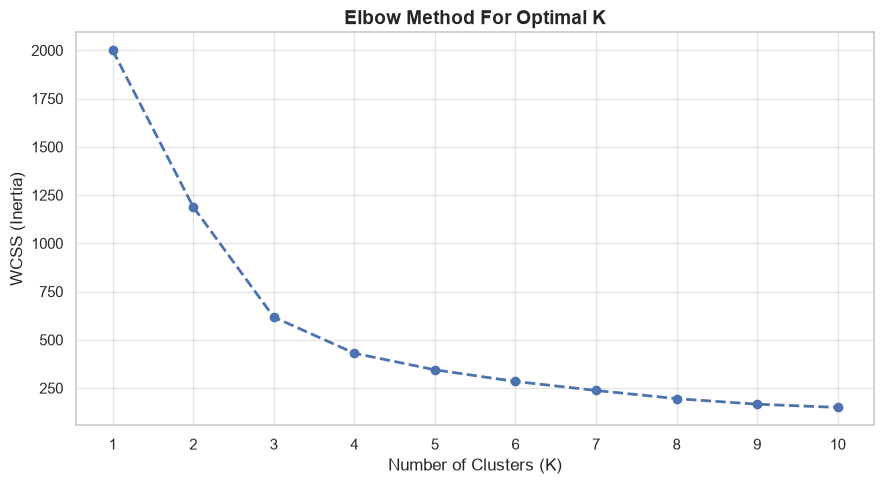

In [4]:
# 3. Data Normalization & K-Means Elbow Method

# Extract RFM numerical features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Calculate Within-Cluster Sum of Squares (WCSS) for K values from 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method Curve
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b', linewidth=2)
plt.title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

### 3. Optimal Clusters (Elbow Method) Observations
- Elbow Point: The WCSS curve shows a clear bend ("elbow") around $K = 3$.
- Cluster Selection: Setting $K = 3$ balances intra-cluster compactness with model simplicity, dividing the customer base into 3 distinct behavioral segments.

In [8]:
# 4. Apply K-Means Clustering (K=3) & Cluster Profiling

# Model Training
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Calculate mean feature values per cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Customer Count'}).reset_index()

# Display Cluster Summary Table
print("--- Cluster Profiling Summary ---")
display(cluster_profile)

--- Cluster Profiling Summary ---


,Cluster,Recency,Frequency,Monetary,Customer Count
0,0,275.347368,1.0,167.881579,380
1,1,87.755102,1.0,211.237245,392
2,2,192.763158,1.0,1357.017544,228


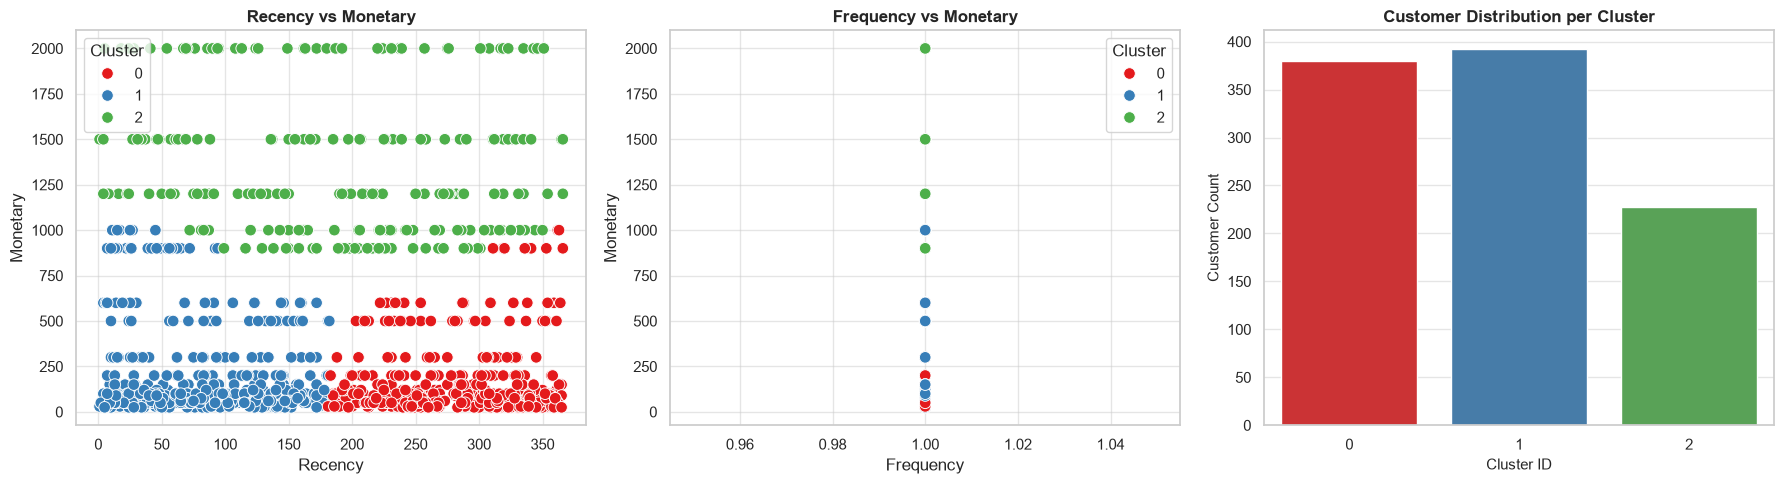

In [9]:
# 5. Visualizing Clusters (Scatter Plots & Bar Chart)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[0], s=70)
axes[0].set_title('Recency vs Monetary', fontsize=12, fontweight='bold')

# Plot 2: Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[1], s=70)
axes[1].set_title('Frequency vs Monetary', fontsize=12, fontweight='bold')

# Plot 3: Number of Customers per Cluster
sns.countplot(data=rfm, x='Cluster', palette='Set1', ax=axes[2], hue='Cluster', legend=False)
axes[2].set_title('Customer Distribution per Cluster', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster ID', fontsize=11)
axes[2].set_ylabel('Customer Count', fontsize=11)

plt.tight_layout()
plt.show()

## Customer Profiles & Marketing Recommendations

Based on the K-Means clustering algorithm ($K=3$), the customer base has been segmented into three distinct groups:

### 1. Cluster 0: High-Value / Loyal Customers (VIPs)
- Profile: High monetary spend, frequent transaction history, and recent purchases.
- Marketing Strategy:
  - VIP Loyalty Programs: Offer exclusive rewards, early access to new product releases, and premium customer service.
  - Upselling & Cross-selling: Recommend premium items and high-end packages to maximize customer lifetime value.

### 2. Cluster 1: At-Risk / Hibernating Customers
- Profile: Higher Recency (longer time since last transaction), lower transaction frequency, and moderate spend.
- Marketing Strategy:
  - Re-engagement Campaigns: Send targeted win-back emails with personalized discount vouchers or "We Miss You" promo codes.
  - Surveys & Feedback: Collect feedback to understand non-responsiveness and remove friction in the purchase journey.

### 3. Cluster 2: Occasional / Price-Sensitive Customers
- Profile: Moderate to low purchase frequency with lower total overall expenditure.
- Marketing Strategy:
  - Incentivized Sales: Offer volume-based discounts (e.g., "Buy 2 Get 1 Free") or limited-time promotional offers to boost purchasing frequency.
  - Targeted Promotions: Recommend budget-friendly product categories to drive steady repeat purchases.